Data: Open University Learning Analytics Dataset (OULAD)

https://www.kaggle.com/datasets/anlgrbz/student-demographics-online-education-dataoulad/data?select=studentAssessment.csv

Research Question: 
Does having higher length of course interaction (from vle table) lead to higher score (student assessment)?

In [21]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Step 1: Data Exploration

## Read in Data

In [2]:
courses = pd.read_csv('Data/courses.csv')
assessments = pd.read_csv('Data/assessments.csv')
stu_assess = pd.read_csv('Data/studentAssessment.csv')
regist = pd.read_csv('Data/studentRegistration.csv')
vle = pd.read_csv('Data/vle.csv')

print(courses.head())
print(assessments.head())
print(stu_assess.head())
print(regist.head())
print(vle.head())

  code_module code_presentation  module_presentation_length
0         AAA             2013J                         268
1         AAA             2014J                         269
2         BBB             2013J                         268
3         BBB             2014J                         262
4         BBB             2013B                         240
  code_module code_presentation  id_assessment assessment_type   date  weight
0         AAA             2013J           1752             TMA   19.0    10.0
1         AAA             2013J           1753             TMA   54.0    20.0
2         AAA             2013J           1754             TMA  117.0    20.0
3         AAA             2013J           1755             TMA  166.0    20.0
4         AAA             2013J           1756             TMA  215.0    30.0
   id_assessment  id_student  date_submitted  is_banked  score
0           1752       11391              18          0   78.0
1           1752       28400              22  

## Analyze the Resource Type for Each Class

* Only include the course that have one activity type throughout the course by keeping rows where the week_from and week_to columns are both missing.

In [3]:
vle_cleaned = vle[(vle['week_from'].isnull()) & (vle['week_to'].isnull())]
#  Class-year-activity level
vle_cleaned_group_act = vle_cleaned.groupby(['code_module', 'code_presentation','activity_type']).size().reset_index(name = 'cnt_act_type')
# Class-year level
vle_cleaned_group = vle_cleaned_group_act.groupby(['code_module', 'code_presentation']).agg(
    tot_cnt = ('cnt_act_type', 'sum'),
    most_freq_act = ('cnt_act_type', 'max')
).reset_index()
vle_comb = vle_cleaned_group_act.merge(vle_cleaned_group, on = ['code_module', 'code_presentation'])
# calculate the percentage of each activity amoung each class
vle_comb['act_percent'] = round((vle_comb['cnt_act_type']*100 / vle_comb['tot_cnt']), 2)
print(vle_comb.describe())


       cnt_act_type     tot_cnt  most_freq_act  act_percent
count    229.000000  229.000000     229.000000   229.000000
mean      22.895197  245.344978     115.489083     9.607336
std       42.720095  125.644824      59.346116    15.654614
min        1.000000   83.000000      32.000000     0.210000
25%        2.000000  173.000000      77.000000     0.980000
50%        6.000000  218.000000      95.000000     2.850000
75%       19.000000  315.000000     182.000000     8.650000
max      236.000000  483.000000     236.000000    81.280000


* find the most frequently used activity type for each class

In [4]:
# find the most frequently used activity type for each class
most_freq_act = vle_comb[vle_comb['cnt_act_type'] == vle_comb['most_freq_act']]
print(most_freq_act)

    code_module code_presentation activity_type  cnt_act_type  tot_cnt  \
6           AAA             2013J      resource            95      208   
15          AAA             2014J      resource            93      199   
24          BBB             2013B      resource           236      315   
34          BBB             2013J      resource           196      245   
44          BBB             2014B      resource           191      235   
55          BBB             2014J      resource            96      173   
64          CCC             2014B      resource            78      191   
73          CCC             2014J      resource            85      218   
84          DDD             2013B      resource           182      428   
95          DDD             2013J       subpage           194      462   
105         DDD             2014B       subpage           193      452   
114         DDD             2014J      resource           169      364   
125         EEE             2013J     

**Conclusion of the analysis**: Most of the materials among different classes are classified as 'resource', which consist of 33%-81% of all the available activities for each class.

## Analyze the Student

* Only include the students that did not drop out


In [5]:
undrop_stu = regist[regist['date_unregistration'].isnull()]
all_crs_stu = undrop_stu.merge(courses, how = 'left', on = ['code_module','code_presentation'])


* Find the assessment of each of the classes that each student took

In [6]:
course_assess= all_crs_stu.merge(assessments, how = 'left', on = ['code_module','code_presentation'])
stu_course_score = course_assess.merge(stu_assess, how = 'left', on = ['id_assessment', 'id_student'])

* Find the final score at the course-student level

In [7]:
stu_course_score = stu_course_score.drop(['date_unregistration'], axis = 1)
stu_course_score = stu_course_score.dropna()

* Make sure the assessment_type only consist of TMA, CMA and Exam

In [8]:
stu_course_score[['assessment_type']].drop_duplicates()

,assessment_type
0,TMA
3732,CMA
85677,Exam


* Separate the Final Exam, TMA and CMA

In [9]:
# Final
final_exam = stu_course_score[stu_course_score['assessment_type'] =='Exam']

# TMA
tma = stu_course_score[stu_course_score['assessment_type'] =='TMA']

# CMA
cma = stu_course_score[stu_course_score['assessment_type'] =='CMA']

In [10]:
print('Tutor Marked Assessment (TMA)')
print(tma.describe())

print('\n\nComputer Marked Assessment (CMA)')
print(cma.describe())

Tutor Marked Assessment (TMA)
         id_student  date_registration  module_presentation_length  \
count  8.953600e+04       89536.000000                89536.000000   
mean   7.095677e+05         -66.699015                  256.048584   
std    5.586499e+05          46.909243                   13.121811   
min    6.516000e+03        -310.000000                  234.000000   
25%    5.045960e+05         -95.000000                  241.000000   
50%    5.872970e+05         -53.000000                  262.000000   
75%    6.424442e+05         -29.000000                  268.000000   
max    2.698588e+06         124.000000                  269.000000   

       id_assessment          date        weight  date_submitted  \
count   89536.000000  89536.000000  89536.000000    89536.000000   
mean    25164.538041     98.571245     16.903335       97.341706   
std      9081.128121     59.760061      8.344443       61.125869   
min      1752.000000     12.000000      0.000000      -11.000000   

**Conclusion of the analysis**:
* There is more TMA than CMA
* Looking at the mean and the percentile distribution (25th, 50th and 75th), students perform better at CMA type of quiz than TMA type of quiz

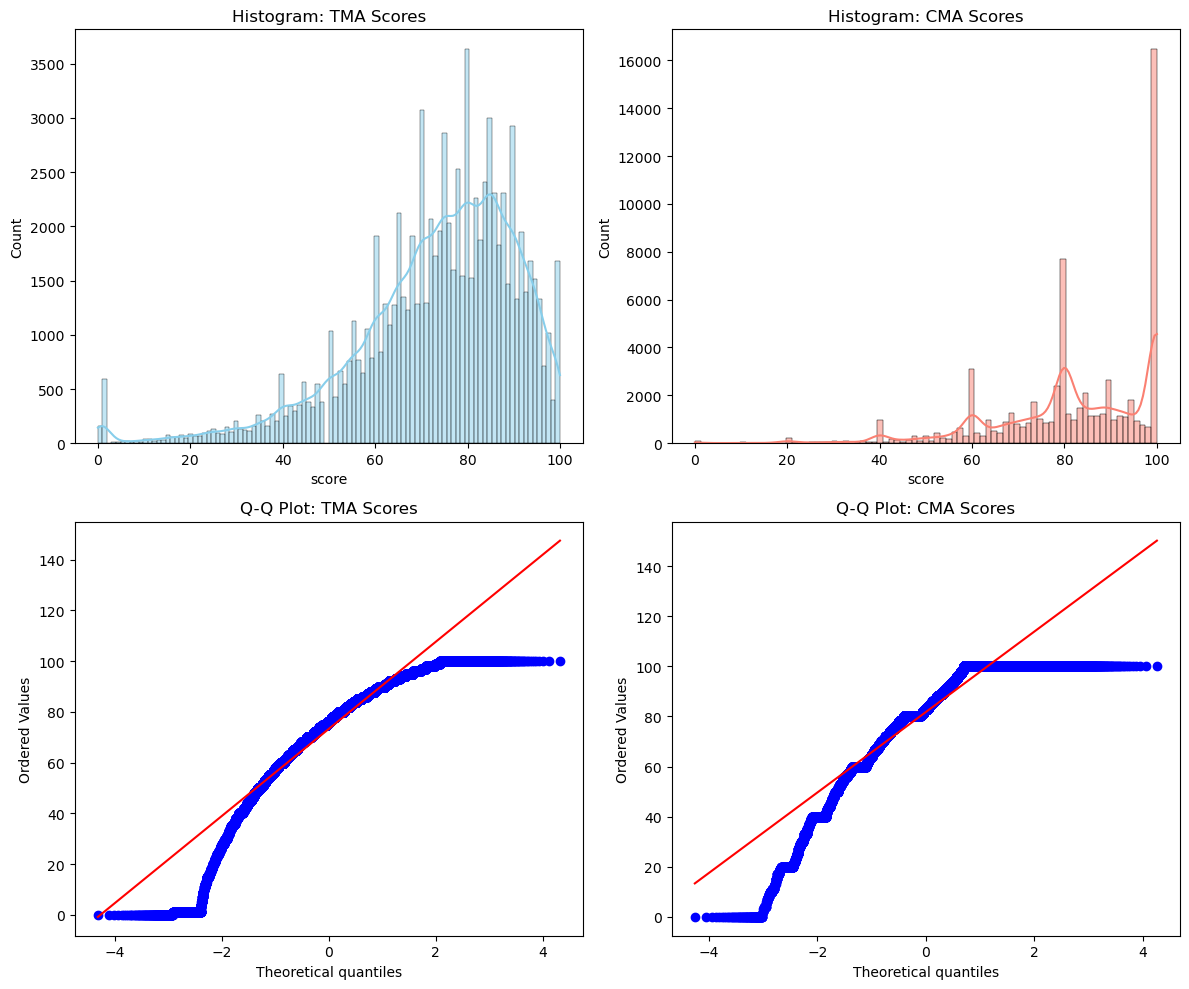

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# TMA
sns.histplot(tma['score'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title("Histogram: TMA Scores")

stats.probplot(tma['score'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot: TMA Scores")

# CMA
sns.histplot(cma['score'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title("Histogram: CMA Scores")

stats.probplot(cma['score'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot: CMA Scores")


plt.tight_layout()
plt.show()

**Comment:** It seems that both the CMA and the TMA data are right skewed. I am going to try to see if taking the log of the score will help the data to be more normally distributed for the Hypothesis Testing.

# Hypothesis Testinig
* Is there significant difference between the mean of the TMA test and the mean of the CMA test?

In [16]:
# Take the mean of the CMA test and the mean of the TMA test 
tma_grp = tma.groupby(['id_assessment'])['score'].mean().reset_index(name = 'test_lvl_mean_score')
cma_grp = cma.groupby(['id_assessment'])['score'].mean().reset_index(name = 'test_lvl_mean_score')

n = len(tma_grp)
m = len(cma_grp)
print(n)
print(m)

106
76


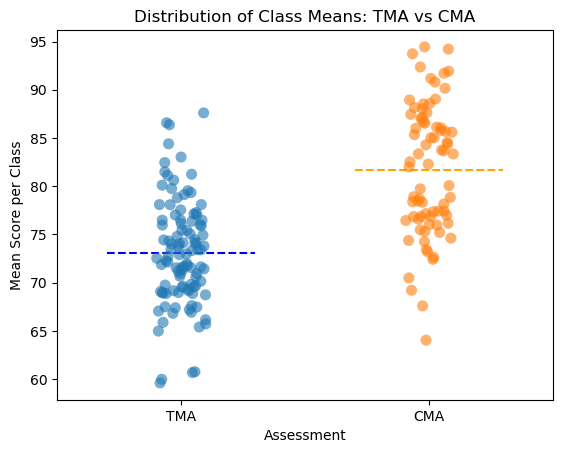

In [34]:
# 1. Organize data into a DataFrame
df = pd.DataFrame({
    'Score': list(tma_grp['test_lvl_mean_score']) + list(cma_grp['test_lvl_mean_score']),
    'Assessment': ['TMA'] * len(tma_grp['test_lvl_mean_score']) + ['CMA'] * len(cma_grp['test_lvl_mean_score'])
})

# 2. Create the Dot Plot (Strip Plot)
sns.stripplot(x='Assessment', y='Score', data=df, hue='Assessment', jitter=True, size=8, alpha=0.6)

# 3. Add horizontal lines for the Grand Means
plt.axhline(y=tma_grp_mean, xmin=0.1, xmax=0.4, 
            color='blue', linestyle='--', label='TMA Mean')
plt.axhline(y=cma_grp_mean, xmin=0.6, xmax=0.9, 
            color='orange', linestyle='--', label='CMA Mean')

plt.title('Distribution of Class Means: TMA vs CMA')
plt.ylabel('Mean Score per Class')
plt.savefig('dot_plot_analysis.png')

### Central Limit Theorem
By CLT, as the number of sample mean increase, the distribution of the sample mean will be approximately normal.

<center>ie. $n \rightarrow\infty,\space\bar{x}\sim N\left(\mu, \frac{\sigma^2}{n}\right)$ </center>

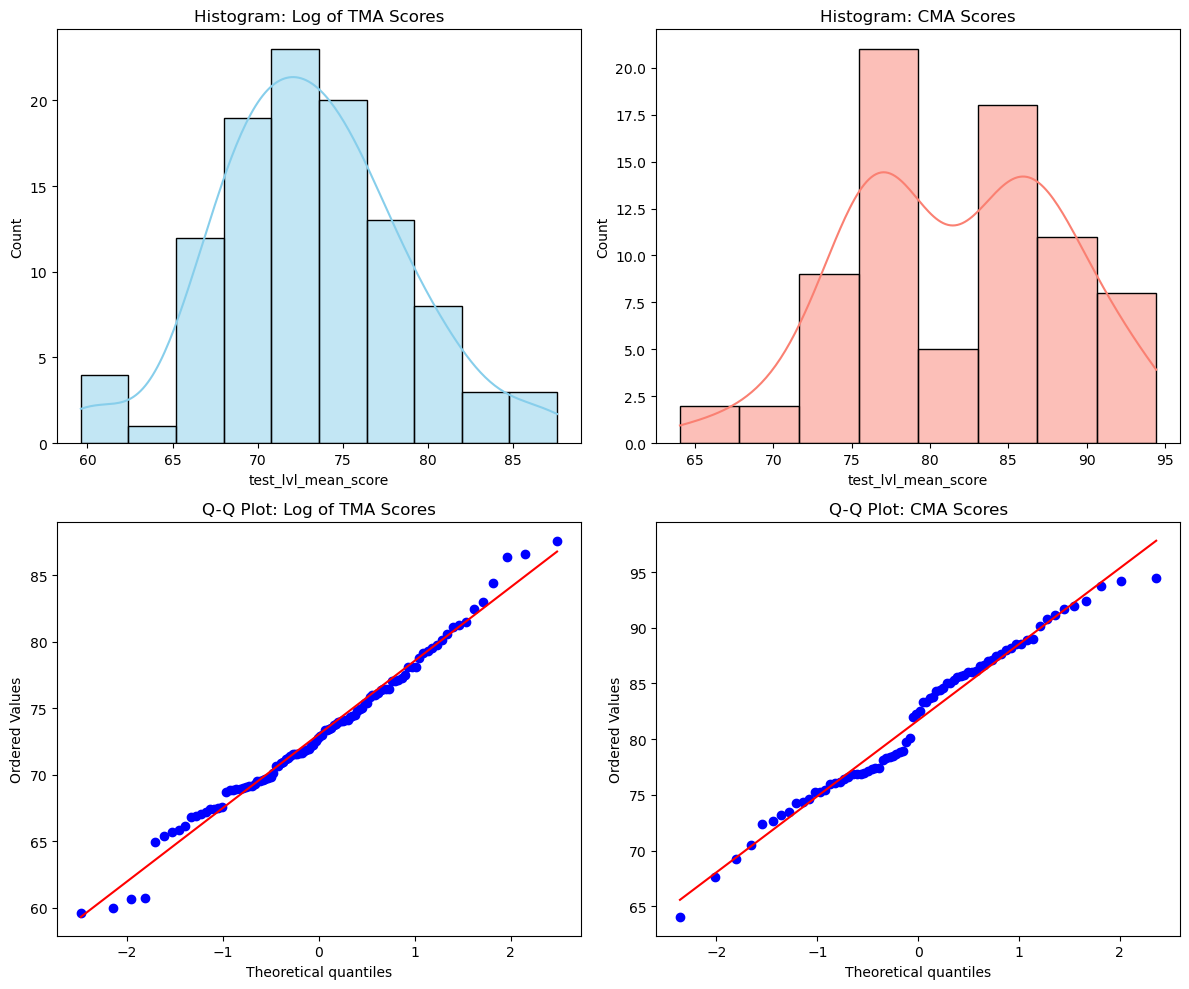

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# TMA
sns.histplot(tma_grp['test_lvl_mean_score'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title("Histogram: Log of TMA Scores")

stats.probplot(tma_grp['test_lvl_mean_score'], dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot: Log of TMA Scores")

# CMA
sns.histplot(cma_grp['test_lvl_mean_score'], kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title("Histogram: CMA Scores")

stats.probplot(cma_grp['test_lvl_mean_score'], dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot: CMA Scores")


plt.tight_layout()
plt.show()

In [26]:
# calculate the standard error
tma_grp_mean = tma_grp['test_lvl_mean_score'].mean()
tma_grp_std = tma_grp['test_lvl_mean_score'].std()
tma_grp_var = tma_grp['test_lvl_mean_score'].var()

cma_grp_mean = cma_grp['test_lvl_mean_score'].mean()
cma_grp_std = cma_grp['test_lvl_mean_score'].std()
cma_grp_var = cma_grp['test_lvl_mean_score'].var()

print(tma_grp_mean)
print(cma_grp_mean)
print(tma_grp_std)
print(cma_grp_std)


73.0578526030691
81.6981860696359
5.487645965945215
6.767688835170332


### F-Test for Sigma
Since the pooled T-test required the numerator follows $N(0,1)$ and the denominator follows the $\chi^2$ distribution, and that $\sigma_{TMA} = \sigma_{CMA} $
<center>$H_0: \sigma^2_{TMA} = \sigma^2_{CMA} $</center>
<center>$H_1: \sigma^2_{TMA} \ne \sigma^2_{CMA} $</center>

In [23]:
f_stat = tma_grp_var / cma_grp_var
print(f_stat)

f_p_val = (1- stats.f.cdf(f_stat, n-1, m-1))*2
print(f_p_val)

0.6574934117162795
1.952678691866805


**Conclusion**: With 95% confidence level, I concluded that $\sigma_{TMA} = \sigma_{CMA} $

In [27]:
s_pooled = np.sqrt(((n-1) * tma_grp_var + (m-1)*cma_grp_var)/ (n+m-2))
print(s_pooled)
t_stat = (tma_grp_mean-cma_grp_mean) / (s_pooled * np.sqrt((1/n) + (1/m)))
print(t_stat)

6.053978503026813
-9.495408743983862


In [28]:
# 1. Perform the T-test
# equal_var=False triggers Welch's T-test (Recommended)
t_stat, p_value = stats.ttest_ind(tma_grp['test_lvl_mean_score'], cma_grp['test_lvl_mean_score'], equal_var=True)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# 2. Interpret the result
alpha = 0.05
if p_value < alpha:
    print("Conclusion: Reject the null hypothesis (Significant difference between means)")
else:
    print("Conclusion: Fail to reject the null hypothesis (No significant difference)")

T-statistic: -9.4954
P-value: 0.0000
Conclusion: Reject the null hypothesis (Significant difference between means)
